# `ClusterStratifiedKFold`: cluster-stratified spatial CV

`ClusterStratifiedKFold` fits a user-supplied clusterer (HDBSCAN, OPTICS, KMeans, ...)
to the input locations, then partitions each cluster's members into `n_splits` parts.
Every test fold draws proportionally from every cluster, so each fold spans all clusters
rather than holding out a single region.

This is the spatial analogue of `StratifiedKFold` where the strata are spatial clusters
discovered at fit time.

In [1]:
import geodatasets
import geopandas
import numpy
import matplotlib.pyplot as plt
import colormaps
from sklearn.cluster import HDBSCAN
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

from geovalidate import ClusterStratifiedKFold

/Users/lw17329/miniforge/envs/geovalidate/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data — King County house sales

We use a random subsample of 2 000 sales from the full King County dataset,
projected to UTM 10N (metres) so that HDBSCAN operates on meaningful distance units.

In [2]:
gdf_full = geopandas.read_file(geodatasets.get_path("geoda.home_sales")).to_crs("EPSG:32610")
gdf_full["log_price"] = numpy.log(gdf_full["price"])

rng = numpy.random.default_rng(42)
idx = rng.choice(len(gdf_full), 2000, replace=False)
gdf = gdf_full.iloc[idx].reset_index(drop=True)
coords = numpy.column_stack([gdf.geometry.x, gdf.geometry.y])

print(f"n = {len(gdf)} sales  |  price ${gdf.price.min():,.0f} – ${gdf.price.max():,.0f}")

n = 2000 sales  |  price $95,000 – $3,635,000


## Basic usage

Pass any sklearn-compatible clusterer. `ClusterStratifiedKFold` clones it internally,
fits to the input coordinates, then stratifies each cluster across folds.

`HDBSCAN(min_cluster_size=30)` finds the dense sub-regions of King County
(Seattle core, Bellevue/Eastside, suburban corridors) and labels sparse rural
points as noise (`label = -1`).

In [3]:
ckf = ClusterStratifiedKFold(
    HDBSCAN(min_cluster_size=30, copy=True),
    n_splits=5,
    random_state=0,
)
splits = list(ckf.split(gdf))

clusters = sorted(set(ckf.labels_) - {-1})
n_noise = int((ckf.labels_ == -1).sum())
print(f"discovered {ckf.n_clusters_} clusters  |  noise points: {n_noise} ({n_noise/len(gdf):.0%})")
print(f"cluster sizes: {sorted([(ckf.labels_==c).sum() for c in clusters], reverse=True)}")
print(f"fold sizes:    {[len(te) for _, te in splits]}")

discovered 9 clusters  |  noise points: 862 (43%)
cluster sizes: [np.int64(366), np.int64(187), np.int64(143), np.int64(117), np.int64(113), np.int64(98), np.int64(78), np.int64(36)]
fold sizes:    [405, 403, 400, 396, 396]


### Visualize clusters and one example fold

Left: HDBSCAN clusters (noise in grey). Right: train vs test assignment for fold 0.
Notice that the test points (orange) are spread across all clusters — not concentrated
in a single geographic region.

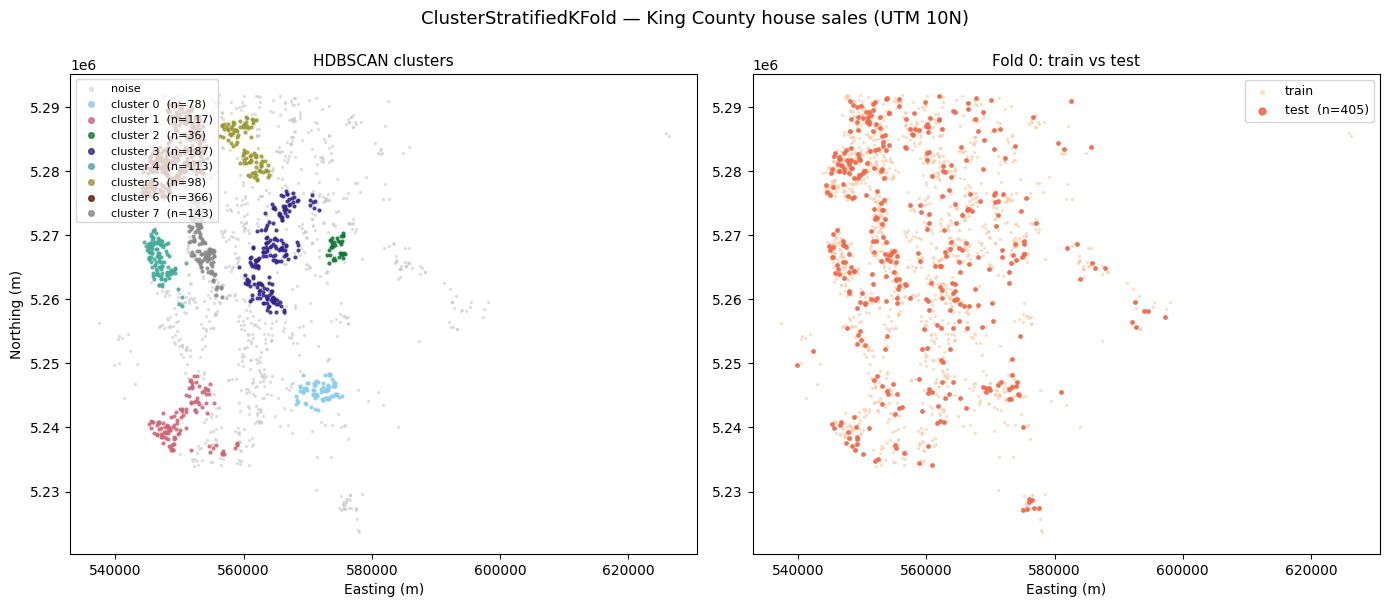

In [4]:
gdf["cluster"] = ckf.labels_

fold0_train, fold0_test = splits[0]
role = numpy.full(len(gdf), "train", dtype=object)
role[fold0_test] = "test"
gdf["fold0_role"] = role

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: cluster map
ax = axes[0]
gdf[gdf.cluster == -1].plot(ax=ax, color="#ccc", markersize=2, alpha=0.5, label="noise")
for fi, c in enumerate(clusters):
    sub = gdf[gdf.cluster == c]
    sub.plot(ax=ax, color=colormaps.safe(fi / max(len(clusters) - 1, 1)),
             markersize=4, alpha=0.8, label=f"cluster {c}  (n={len(sub)})")
ax.set_title("HDBSCAN clusters", fontsize=11)
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
ax.set_aspect("equal")
ax.legend(fontsize=8, markerscale=2, loc="upper left")

# Panel 2: fold 0 train / test
ax2 = axes[1]
gdf[gdf.fold0_role == "train"].plot(ax=ax2, color=colormaps.peach(0.2),
                                    markersize=2, alpha=0.5, label="train")
gdf[gdf.fold0_role == "test"].plot(ax=ax2, color=colormaps.peach(0.8),
                                   markersize=6, alpha=0.9, label=f"test  (n={len(fold0_test)})")
ax2.set_title("Fold 0: train vs test", fontsize=11)
ax2.set_xlabel("Easting (m)")
ax2.set_aspect("equal")
ax2.legend(fontsize=9, markerscale=2)

fig.suptitle("ClusterStratifiedKFold — King County house sales (UTM 10N)", fontsize=13)
fig.tight_layout()
plt.show()

## Noise handling

Density-based clusterers (HDBSCAN, OPTICS) label outlier points with `-1`.
`ClusterStratifiedKFold` exposes three policies:

- `noise='stratify'` (default): distribute noise across folds like any other cluster.
- `noise='drop'`: exclude noise from both train and test.
- `noise='train_only'`: noise is in every train set, never in any test set.

In [5]:
noise_idx = numpy.flatnonzero(ckf.labels_ == -1)

for mode in ("stratify", "drop", "train_only"):
    ckf_m = ClusterStratifiedKFold(
        HDBSCAN(min_cluster_size=30, copy=True),
        n_splits=5, noise=mode, random_state=0,
    )
    splits_m = list(ckf_m.split(gdf))
    train0, test0 = splits_m[0]
    train_noise = int(numpy.isin(noise_idx, train0).sum())
    test_noise  = int(numpy.isin(noise_idx, test0).sum())
    fold_sizes  = [len(te) for _, te in splits_m]
    print(
        f"noise={mode:11s}  "
        f"fold0 train noise={train_noise:3d}, test noise={test_noise:3d}  "
        f"fold sizes={fold_sizes}"
    )

noise=stratify     fold0 train noise=689, test noise=173  fold sizes=[405, 403, 400, 396, 396]
noise=drop         fold0 train noise=  0, test noise=  0  fold sizes=[232, 230, 228, 224, 224]
noise=train_only   fold0 train noise=862, test noise=  0  fold sizes=[232, 230, 228, 224, 224]


## Pre-fitted clusterer

If you have already fit a clusterer (e.g. to inspect it, tune it, or share it across
folds and other code), pass it in directly: `ClusterStratifiedKFold` will detect the
`labels_` attribute and skip refitting.

In [6]:
fitted = HDBSCAN(min_cluster_size=30, copy=True).fit(coords)
print(f"pre-fit found {len(set(fitted.labels_) - {-1})} clusters")

ckf_pre = ClusterStratifiedKFold(fitted, n_splits=5, random_state=0)
splits_pre = list(ckf_pre.split(gdf))

assert ckf_pre.clusterer_ is fitted, "pre-fitted clusterer should be used as-is"
print(f"fold sizes: {[len(te) for _, te in splits_pre]}")

pre-fit found 8 clusters
fold sizes: [405, 403, 400, 396, 396]


## Cross-validation example

Predict log(price) from structural features.  Because each fold's test set spans
all geographic clusters, fold-to-fold RMSE variance reflects model generalisation
rather than spatial coverage differences.

In [7]:
feat_cols = ["sqft_liv", "bedrooms", "bathrooms", "grade"]
y = gdf["log_price"].values
X = gdf[feat_cols].fillna(0).values

rmse_per_fold = []
for train, test in splits:
    lr = LinearRegression().fit(X[train], y[train])
    rmse_per_fold.append(root_mean_squared_error(y[test], lr.predict(X[test])))

print(f"RMSE per fold: {[f'{r:.3f}' for r in rmse_per_fold]}")
print(f"mean RMSE: {numpy.mean(rmse_per_fold):.3f}  ±  {numpy.std(rmse_per_fold):.3f}")

RMSE per fold: ['0.328', '0.356', '0.367', '0.343', '0.357']
mean RMSE: 0.350  ±  0.014
